# Analysis

## GIN
Analysis of the results obtained from the GIN model on the test set. We will use the best model (the one with 3 node features, trained on the larger dataset) for this analysis.

In [1]:
import json

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch
import torch_geometric.loader
import torch_geometric.utils
import torch_geometric.data
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from scipy import stats

from models import GIN
from utils import paut_size_from_torch, regularity_check, aut_grp_size_from_torch

sns.set_theme()

### Confusion Matrix

In [2]:
with open("results/baseline/best_config.json", "r") as f:
    config = json.load(f)

test_dataset = torch.load("dataset/test_dataset.pt", weights_only=False)
test_loader = torch_geometric.loader.DataLoader(
    test_dataset, batch_size=config["batch_size"], shuffle=False
)

number_of_features = test_dataset[0].num_node_features
model = GIN(
    number_of_features, config["hidden_dim"], config["num_layers"], config["dropout"]
)
model.load_state_dict(
    torch.load(
        "results/baseline/larger_dataset/best_model.pt",
        map_location=torch.device("cpu"),
    )
)

<All keys matched successfully>

In [3]:
model.eval()
records = []
true_labels = []
predictions = []
sample_idx = 0

for batch in test_loader:
    with torch.no_grad():
        logits = model(batch).view(-1)
        probs = torch.sigmoid(logits)
        pred = (logits > 0).float()

    for i, graph in enumerate(batch.to_data_list()):
        true_label = int(graph.y.item())
        pred_label = int(pred[i].item())
        records.append(
            {
                "sample_idx": sample_idx,
                "num_nodes": graph.num_nodes,
                "regular": regularity_check(graph),
                "paut_size": paut_size_from_torch(graph),
                "aut_grp_size": aut_grp_size_from_torch(graph),
                "true_label": true_label,
                "prediction": pred_label,
                "pred_prob": float(probs[i].item()),
                "correct": pred_label == true_label,
            }
        )
        true_labels.append(true_label)
        predictions.append(pred_label)
        sample_idx += 1

predictions_df = pd.DataFrame(records)
predictions_df["paut_relative_size"] = (
    predictions_df["paut_size"] / predictions_df["num_nodes"]
)
predictions_df["error"] = (
    predictions_df["true_label"] != predictions_df["prediction"]
).astype(int)

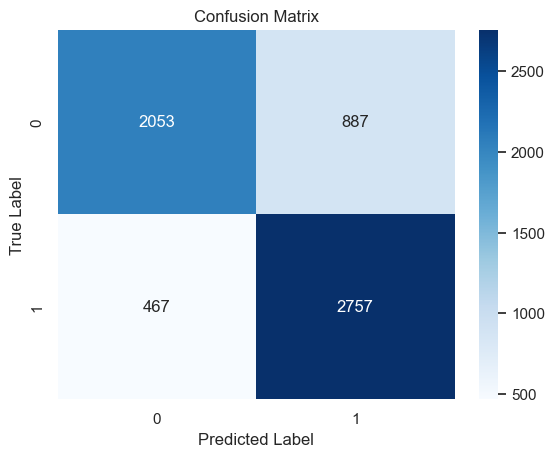

In [4]:
cm = confusion_matrix(predictions_df["true_label"], predictions_df["prediction"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### Graph regularity effect

In [5]:
wrong_predictions_df = predictions_df[~predictions_df["correct"]]

print(
    f"Number of wrong predictions: {len(wrong_predictions_df[wrong_predictions_df['regular']]) / len(wrong_predictions_df):.2%} of wrong predictions are regular graphs."
)

Number of wrong predictions: 20.09% of wrong predictions are regular graphs.


### Graph size effect

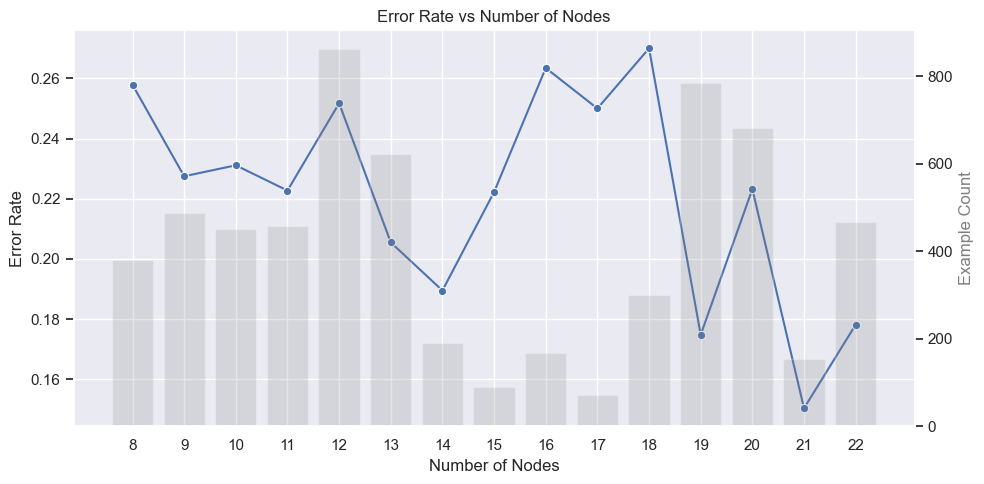

In [6]:
error_rate_by_nodes = (
    predictions_df.groupby("num_nodes", observed=True)["correct"]
    .agg(error_rate=lambda x: 1 - x.mean(), count="count")
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Convert to string so both plots treat x as categorical
nodes_str = error_rate_by_nodes["num_nodes"].astype(str)
plot_data = error_rate_by_nodes.copy()
plot_data["num_nodes"] = nodes_str

ax2 = ax1.twinx()
sns.barplot(
    data=plot_data, x="num_nodes", y="count", ax=ax2, color="gray", alpha=0.2, zorder=1
)
ax2.set_ylabel("Example Count", color="gray")

sns.lineplot(
    data=plot_data, x="num_nodes", y="error_rate", ax=ax1, marker="o", zorder=3
)

ax1.set_xlabel("Number of Nodes")
ax1.set_ylabel("Error Rate")
ax1.set_axisbelow(True)
ax2.grid(False)

plt.title("Error Rate vs Number of Nodes")
plt.tight_layout()
plt.show()

In [7]:
corr, pvalue = stats.spearmanr(
    error_rate_by_nodes["num_nodes"], error_rate_by_nodes["error_rate"]
)
print(f"Spearman r = {corr:.3f}, p = {pvalue:.4f}")

Spearman r = -0.418, p = 0.1212


### Automorphism group size effect

In [8]:
features = ["num_nodes", "paut_size", "aut_grp_size", "paut_relative_size"]
X = predictions_df[features]
y = predictions_df["error"]
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
for f, imp in sorted(zip(features, rf.feature_importances_), key=lambda x: -x[1]):
    print(f"{f}: {imp:.4f}")

aut_grp_size: 0.5838
paut_relative_size: 0.2194
num_nodes: 0.1007
paut_size: 0.0961


### Effect of relative partial automorphism size

In [9]:
bins = np.linspace(0.5, 0.8, 12)  # 12 bins, width 0.025
predictions_df["rel_bin"] = pd.cut(
    predictions_df["paut_relative_size"], bins, include_lowest=True
)

grouped = predictions_df.groupby("rel_bin", observed=True)["correct"]
error_rate = grouped.apply(lambda x: 1 - x.mean()).reset_index()
error_rate.columns = ["rel_bin", "error_rate"]
error_rate["bin_midpoint"] = [(b.left + b.right) / 2 for b in error_rate["rel_bin"]]

error_rate

,rel_bin,error_rate,bin_midpoint
0,"(0.499, 0.527]",0.119464,0.5130
1,"(0.527, 0.555]",0.167797,0.5410
2,"(0.555, 0.582]",0.237154,0.5685
3,"(0.582, 0.609]",0.324207,0.5955
4,"(0.609, 0.636]",0.272066,0.6225
5,"(0.636, 0.664]",0.279412,0.6500
6,"(0.664, 0.691]",0.284153,0.6775
7,"(0.691, 0.718]",0.244216,0.7045
8,"(0.718, 0.745]",0.199367,0.7315
9,"(0.745, 0.773]",0.147844,0.7590


In [13]:
corr, pvalue = stats.spearmanr(
    predictions_df["paut_relative_size"], predictions_df["error"]
)
print(f"Spearman r = {corr:.3f}, p = {pvalue:.4f}")

Spearman r = 0.030, p = 0.0201


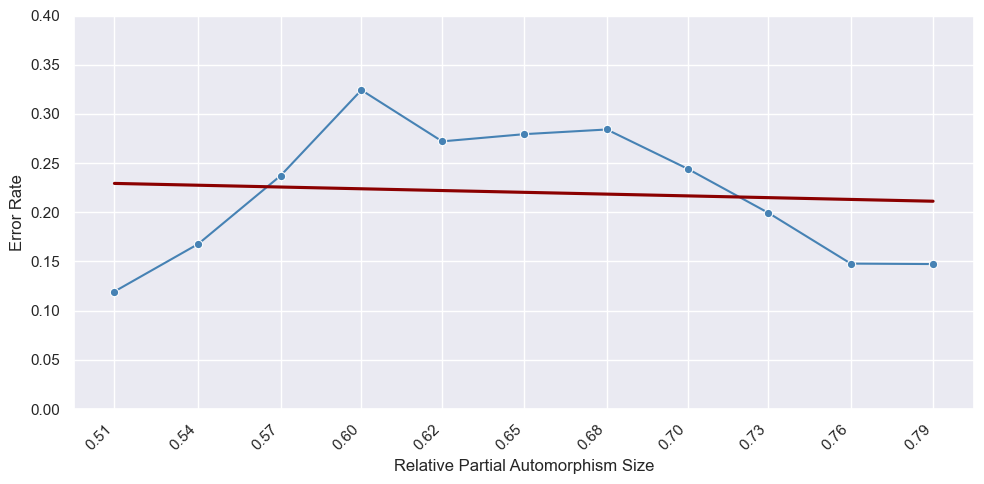

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=error_rate,
    x="bin_midpoint",
    y="error_rate",
    marker="o",
    color="steelblue",
    ax=ax,
)

# Add linear regression line
sns.regplot(
    data=error_rate,
    x="bin_midpoint",
    y="error_rate",
    scatter=False,  # don't duplicate points
    ci=None,  # remove confidence interval if you want clean line
    color="darkred",
    ax=ax,
    order=1,
)

ax.set_ylim(0, 0.4)
ax.set_xlabel("Relative Partial Automorphism Size")
ax.set_ylabel("Error Rate")
ax.set_xticks(error_rate["bin_midpoint"])
ax.set_xticklabels(
    [f"{x:.2f}" for x in error_rate["bin_midpoint"]], rotation=45, ha="right"
)
plt.title("Error Rate vs Relative Partial Automorphism Size")
plt.tight_layout()
plt.show()